<a href="https://colab.research.google.com/github/Gakwaya011/athlete-recovery-AI/blob/main/ML/notebooks/energy_expenditure_using_sensors_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Formatting for visuals
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Cell 2: Load Data
try:
    # Adjust the filename if yours is named differently (e.g., 'calories.csv')
    df = pd.read_csv('calories.csv')

    print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
    display(df.head())
except FileNotFoundError:
    print("Error: Please ensure your dataset file is in the same folder as this notebook.")

Dataset loaded successfully with 15000 rows and 9 columns.


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
# Cell 3: Data Checking & Preprocessing
print("Checking for missing values:")
print(df.isnull().sum())

# Drop User_ID as it has no physiological predictive value
if 'User_ID' in df.columns:
    df = df.drop(columns=['User_ID'])

# Convert 'Gender' from text to numeric (male = 0, female = 1)
# Note: based on your snippet, the values are lowercase 'male' and 'female'
df['Gender'] = df['Gender'].map({'male': 0, 'female': 1})

print("\nData after preprocessing:")
display(df.describe())

Checking for missing values:
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Data after preprocessing:


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.503533,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,0.500004,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,0.000000,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,0.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.000000,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.000000,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


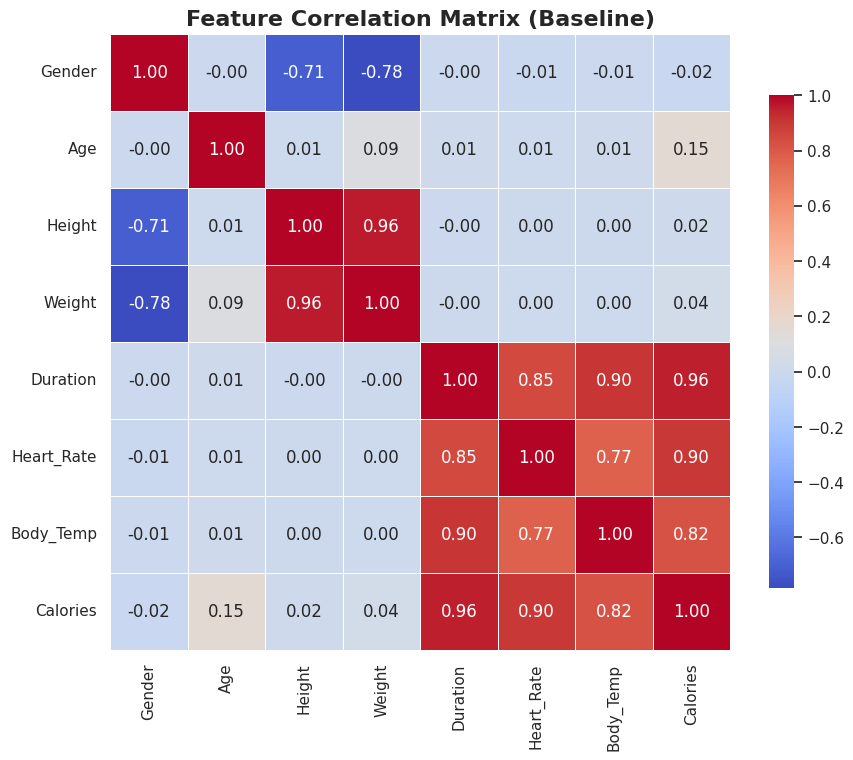

In [5]:
# Cell 4: Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

# Create a heatmap
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Feature Correlation Matrix (Baseline)', fontsize=16, fontweight='bold')
plt.show()

In [6]:
# Cell 5: Train/Test Split
# Here we keep ALL features to establish our baseline
X = df.drop(columns=['Calories'])
y = df['Calories']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (12000, 7)
Testing features shape: (3000, 7)


In [7]:
# Cell 6: Train XGBoost Model
# Initialize the model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Train the model
print("Training XGBoost Baseline Model...")
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate Accuracy Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print("BASELINE MODEL RESULTS (With Wearable Sensors):")
print(f"Mean Absolute Error (MAE): {mae:.2f} calories")
print(f"R-squared Score (R2): {r2:.4f}")
print("-" * 30)

Training XGBoost Baseline Model...
------------------------------
BASELINE MODEL RESULTS (With Wearable Sensors):
Mean Absolute Error (MAE): 1.47 calories
R-squared Score (R2): 0.9989
------------------------------
